In [2]:
# CELL 1 - IMPORTS
import os
import json
import sys
import datetime
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.efficientnet import preprocess_input
import cv2
import torch
import requests
from PIL import Image

# Import Groq insights
from groq_insights import get_meal_insights, generate_weekly_summary

print("✅ All imports done!")

✅ All imports done!


In [3]:
# CELL 2 - CONFIG & PATHS
import os
import sys

# hardcoded path — no relative path issues
BASE_DIR    = r"C:\Users\KIIT0001\OneDrive\Documents\NutriLens"
MODEL_PATH  = os.path.join(BASE_DIR, "saved_models", "food_classifier.h5")
LABELS_PATH = os.path.join(BASE_DIR, "saved_models", "labels.json")
LOG_PATH    = os.path.join(BASE_DIR, "daily_log.json")
IMAGE_SIZE  = (224, 224)

sys.path.append(os.path.join(BASE_DIR, "utils"))
from calorie_db import get_nutrition, get_calories_for_weight

print("✅ Config ready!")
print(f"   Model exists  : {os.path.exists(MODEL_PATH)}")
print(f"   Labels exists : {os.path.exists(LABELS_PATH)}")

✅ Config ready!
   Model exists  : True
   Labels exists : True


In [4]:
# CELL 3 - LOAD FOOD CLASSIFIER MODEL + LABELS
print("Loading food classifier model...")
food_model  = load_model(MODEL_PATH)

with open(LABELS_PATH, 'r') as f:
    labels_dict = json.load(f)
labels_dict = {int(k): v for k, v in labels_dict.items()}

print(f"✅ Food classifier loaded! Classes: {len(labels_dict)}")

Loading food classifier model...


✅ Food classifier loaded! Classes: 22


In [5]:
# CELL 4 - LOAD MiDaS DEPTH MODEL
print("Loading MiDaS depth model...")
midas = torch.hub.load("intel-isl/MiDaS", "MiDaS_small", trust_repo=True)
midas.eval()
midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms", trust_repo=True)
transform = midas_transforms.small_transform
device    = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
midas.to(device)
print(f"✅ MiDaS loaded on: {device}")

Loading MiDaS depth model...


Using cache found in C:\Users\KIIT0001/.cache\torch\hub\intel-isl_MiDaS_master
c:\Users\KIIT0001\anaconda3\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Loading weights:  None


Using cache found in C:\Users\KIIT0001/.cache\torch\hub\rwightman_gen-efficientnet-pytorch_master


✅ MiDaS loaded on: cpu


Using cache found in C:\Users\KIIT0001/.cache\torch\hub\intel-isl_MiDaS_master


In [6]:
# CELL 5 - ALL CORE FUNCTIONS

# ── Food prediction ───────────────────────────────────────
def predict_food(img_path):
    img       = load_img(img_path, target_size=IMAGE_SIZE)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    predictions     = food_model.predict(img_array, verbose=0)
    predicted_index = np.argmax(predictions[0])
    confidence      = predictions[0][predicted_index] * 100
    predicted_food  = labels_dict[predicted_index]

    top3 = [
        (labels_dict[i], round(predictions[0][i] * 100, 1))
        for i in np.argsort(predictions[0])[::-1][:3]
    ]
    return predicted_food, confidence, top3


# ── Depth + weight estimation ─────────────────────────────
def estimate_weight(img_path, food_name):
    img_bgr     = cv2.imread(img_path)
    img_rgb     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    input_batch = transform(img_rgb).to(device)

    with torch.no_grad():
        depth_map = midas(input_batch)
        depth_map = torch.nn.functional.interpolate(
            depth_map.unsqueeze(1),
            size=img_rgb.shape[:2],
            mode="bicubic",
            align_corners=False,
        ).squeeze()

    depth_np         = depth_map.cpu().numpy()
    depth_normalized = (depth_np - depth_np.min()) / (depth_np.max() - depth_np.min())

    h, w        = depth_normalized.shape
    food_region = depth_normalized[int(h*.2):int(h*.8), int(w*.2):int(w*.8)]
    avg_depth   = np.mean(food_region)

    nutrition = get_nutrition(food_name)
    if nutrition:
        base_weight      = nutrition["serving_size_g"]
        multiplier       = 0.7 + (avg_depth * 0.8)
        estimated_weight = round(base_weight * multiplier)
        estimated_weight = max(
            round(base_weight * 0.5),
            min(round(base_weight * 2.0), estimated_weight)
        )
    else:
        estimated_weight = 200

    return round(estimated_weight), depth_normalized


# ── Barcode lookup ────────────────────────────────────────
def lookup_barcode(barcode):
    url      = f"https://world.openfoodfacts.org/api/v0/product/{barcode}.json"
    try:
        response = requests.get(url, timeout=10)
    except Exception as e:
        print(f"❌ Network error: {e}")
        return None

    if response.status_code != 200:
        print("❌ Could not reach Open Food Facts API")
        return None

    data = response.json()
    if data.get('status') != 1:
        print(f"❌ Barcode {barcode} not found in database")
        return None

    product    = data['product']
    nutriments = product.get('nutriments', {})
    calories   = nutriments.get('energy-kcal_100g') or \
                 nutriments.get('energy_100g', 0)
    if calories and calories > 500:
        calories = round(calories / 4.184)

    return {
        'name'    : product.get('product_name', 'Unknown'),
        'calories': round(float(calories)) if calories else 0,
        'protein' : round(float(nutriments.get('proteins_100g', 0)), 1),
        'carbs'   : round(float(nutriments.get('carbohydrates_100g', 0)), 1),
        'fat'     : round(float(nutriments.get('fat_100g', 0)), 1),
    }


# ── Decode barcode from image ─────────────────────────────
def decode_barcode_from_image(img_path):
    # try pyzbar first (handles EAN-13, UPC, etc.)
    try:
        from pyzbar.pyzbar import decode as zbar_decode
        decoded = zbar_decode(Image.open(img_path))
        if decoded:
            return decoded[0].data.decode('utf-8')
    except ImportError:
        pass

    # fallback to OpenCV QR detector
    img      = cv2.imread(img_path)
    detector = cv2.QRCodeDetector()
    data, _, _ = detector.detectAndDecode(img)
    return data if data else None


# ── Daily log functions ───────────────────────────────────
def load_log():
    today = datetime.date.today().isoformat()
    if os.path.exists(LOG_PATH):
        try:
            with open(LOG_PATH, 'r') as f:
                content = f.read().strip()
                all_logs = json.loads(content) if content else {}
        except (json.JSONDecodeError, ValueError):
            all_logs = {}
    else:
        all_logs = {}
    return all_logs.get(today, []), all_logs, today


def save_log(entry):
    today_log, all_logs, today = load_log()
    if today not in all_logs:
        all_logs[today] = []
    all_logs[today].append(entry)
    with open(LOG_PATH, 'w') as f:
        json.dump(all_logs, f, indent=4)
    print(f"\n✅ Logged: {entry['food']}  —  {entry['calories']} kcal  [{entry['time']}]")


def show_daily_summary():
    today_log, _, today = load_log()

    print("\n" + "=" * 55)
    print(f"  DAILY FOOD LOG  —  {today}")
    print("=" * 55)

    if not today_log:
        print("  No food logged today yet.")
        print("=" * 55)
        return

    total_cal  = 0
    total_pro  = 0
    total_carb = 0
    total_fat  = 0

    for i, entry in enumerate(today_log, 1):
        method = "📷" if entry['method'] == 'photo' else "🔍"
        print(f"  {i}. {method} {entry['food'].upper().replace('_',' '):<28}"
              f"{entry['weight']:>4}g   {entry['calories']:>4} kcal"
              f"   [{entry['time']}]")
        total_cal  += entry['calories']
        total_pro  += entry.get('protein', 0)
        total_carb += entry.get('carbs', 0)
        total_fat  += entry.get('fat', 0)

    print("─" * 55)
    print(f"  Total calories : {total_cal} kcal")
    print(f"  Total protein  : {round(total_pro, 1)} g")
    print(f"  Total carbs    : {round(total_carb, 1)} g")
    print(f"  Total fat      : {round(total_fat, 1)} g")

    # progress bar toward 2000 kcal daily goal
    goal     = 2000
    progress = min(total_cal / goal, 1.0)
    filled   = int(progress * 40)
    bar      = "█" * filled + "░" * (40 - filled)
    status   = "✅ Goal reached!" if total_cal >= goal else f"{goal - total_cal} kcal remaining"
    print(f"\n  [{bar}]")
    print(f"  {total_cal} / {goal} kcal  —  {status}")
    print("=" * 55)


print("✅ All functions ready!")

✅ All functions ready!



✅ Image: download (1).jpg
Step 1: Predicting food...
   Predicted : samosa  (100.0%)
Step 2: Estimating portion size...
   Weight    : 124g


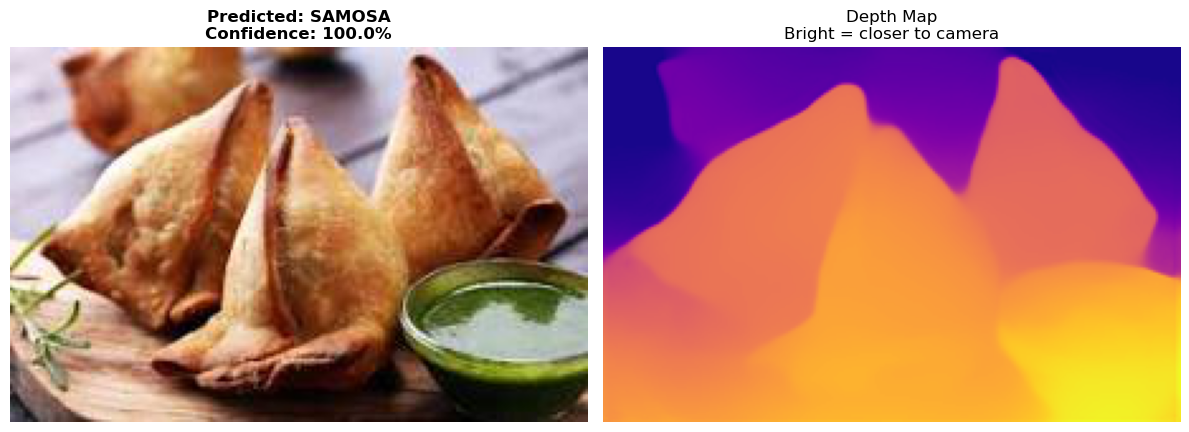

  Food      : SAMOSA
  Confidence: 100.0%
  Weight    : 124g
  Calories  : 325 kcal
  Protein   : 6.2g
  Carbs     : 37.2g
  Fat       : 17.4g
-------------------------------------------------------
Top 3 predictions:
  1. samosa                    100.0%
  2. pakode                    0.0%
  3. dosa                      0.0%

✅ Logged: samosa  —  325 kcal  [11:28]

  DAILY FOOD LOG  —  2026-03-17
  1. 📷 JALEBI                       138g    497 kcal   [11:27]
  2. 📷 SAMOSA                       124g    325 kcal   [11:28]
───────────────────────────────────────────────────────
  Total calories : 822 kcal
  Total protein  : 9.0 g
  Total carbs    : 126.9 g
  Total fat      : 31.2 g

  [████████████████░░░░░░░░░░░░░░░░░░░░░░░░]
  822 / 2000 kcal  —  1178 kcal remaining

🤖 Getting Groq insight...

Gemini says: Namaste! I'd be happy to help. 

1. Not extremely healthy, given high fat content and relatively low protein.
2. It's a significant source of complex carbohydrates from wheat flour a

In [8]:
# CELL 6 - OPTION 1: PHOTO UPLOAD → CALORIE ESTIMATION
# ─────────────────────────────────────────────────────
# Enter the full path to a food image on your PC
# Example: C:/Users/KIIT0001/Pictures/biryani.jpg

img_path = input("📷 Enter food image path: ").strip().strip('"')

if not os.path.exists(img_path):
    print(f"❌ Image not found: {img_path}")
else:
    print(f"\n✅ Image: {os.path.basename(img_path)}")

    # Step 1 — predict food
    print("Step 1: Predicting food...")
    food, confidence, top3 = predict_food(img_path)
    print(f"   Predicted : {food}  ({confidence:.1f}%)")

    # Step 2 — estimate weight
    print("Step 2: Estimating portion size...")
    weight, depth_map = estimate_weight(img_path, food)
    print(f"   Weight    : {weight}g")

    # Step 3 — calculate nutrition
    nutrition = get_nutrition(food)
    calories  = get_calories_for_weight(food, weight)

    # Step 4 — show results
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(load_img(img_path))
    axes[0].set_title(
        f"Predicted: {food.upper().replace('_', ' ')}\n"
        f"Confidence: {confidence:.1f}%",
        fontsize=12, fontweight='bold'
    )
    axes[0].axis('off')
    axes[1].imshow(depth_map, cmap='plasma')
    axes[1].set_title("Depth Map\nBright = closer to camera", fontsize=12)
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

    print("=" * 55)
    print(f"  Food      : {food.upper().replace('_', ' ')}")
    print(f"  Confidence: {confidence:.1f}%")
    print(f"  Weight    : {weight}g")
    print(f"  Calories  : {calories} kcal")
    if nutrition:
        m = weight / 100
        print(f"  Protein   : {round(nutrition['protein_per_100g'] * m, 1)}g")
        print(f"  Carbs     : {round(nutrition['carbs_per_100g']   * m, 1)}g")
        print(f"  Fat       : {round(nutrition['fat_per_100g']     * m, 1)}g")
    print("-" * 55)
    print("Top 3 predictions:")
    for i, (f_, c_) in enumerate(top3, 1):
        print(f"  {i}. {f_:<25} {c_}%")
    print("=" * 55)

    # Step 5 — ask to log
    log_choice = input("\nLog this to daily diary? (y/n): ").strip().lower()
    if log_choice == 'y':
        save_log({
            'food'    : food,
            'weight'  : weight,
            'calories': calories,
            'protein' : round(nutrition['protein_per_100g'] * weight/100, 1) if nutrition else 0,
            'carbs'   : round(nutrition['carbs_per_100g']   * weight/100, 1) if nutrition else 0,
            'fat'     : round(nutrition['fat_per_100g']     * weight/100, 1) if nutrition else 0,
            'method'  : 'photo',
            'time'    : datetime.datetime.now().strftime("%H:%M")
        })
        show_daily_summary()
        print("\n🤖 Getting Groq insight...")
        insight = get_meal_insights(
              food_name = food,
              portion_grams = weight,
              calories = calories,
              protein  = round(nutrition['protein_per_100g'] * weight/100, 1) if nutrition else 0,
              carbs    = round(nutrition['carbs_per_100g']   * weight/100, 1) if nutrition else 0,
              fat      = round(nutrition['fat_per_100g']     * weight/100, 1) if nutrition else 0,
              meal_type = "meal")
        print(f"\nGemini says: {insight}")
    else:
        print("Skipped logging.")

In [10]:
# CELL 7 - OPTION 2: LIVE WEBCAM BARCODE SCANNER
# Hold barcode in front of webcam — auto detects
# Press Q to quit after scanning

from pyzbar.pyzbar import decode as zbar_decode

print("🔍 Starting barcode scanner...")
print("   Hold barcode in front of webcam")
print("   Press Q to quit after scanning\n")

cap            = cv2.VideoCapture(0)
detected_codes = set()
scan_result    = None

while True:
    isTrue, frame = cap.read()
    if not isTrue:
        print("❌ Could not access webcam")
        break

    barcodes = zbar_decode(frame)

    for barcode in barcodes:
        barcode_data = barcode.data.decode('utf-8')
        x, y, w, h   = barcode.rect

        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(frame, barcode_data, (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        cv2.putText(frame, "Press Q to continue", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

        if barcode_data not in detected_codes:
            detected_codes.add(barcode_data)
            scan_result = barcode_data
            print(f"✅ Barcode detected: {barcode_data}")

    cv2.imshow("NutriLens — Barcode Scanner (Press Q to quit)", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

# ── Lookup + log ──────────────────────────────────────────
if not scan_result:
    print("❌ No barcode detected — try again in better lighting")
else:
    print(f"\nLooking up product: {scan_result}")
    result = lookup_barcode(scan_result)

    if result:
        print("\n" + "=" * 55)
        print(f"  Product  : {result['name']}")
        print(f"  Per 100g ")
        print(f"  Calories : {result['calories']} kcal")
        print(f"  Protein  : {result['protein']}g")
        print(f"  Carbs    : {result['carbs']}g")
        print(f"  Fat      : {result['fat']}g")
        print("=" * 55)

        weight = int(input("\nHow many grams did you eat? "))
        m      = weight / 100
        cals   = round(result['calories'] * m)

        print(f"\n  For {weight}g:")
        print(f"  Calories : {cals} kcal")
        print(f"  Protein  : {round(result['protein'] * m, 1)}g")
        print(f"  Carbs    : {round(result['carbs']   * m, 1)}g")
        print(f"  Fat      : {round(result['fat']     * m, 1)}g")

        log_choice = input("\nLog this to daily diary? (y/n): ").strip().lower()
        if log_choice == 'y':
            save_log({
                'food'    : result['name'],
                'weight'  : weight,
                'calories': cals,
                'protein' : round(result['protein'] * m, 1),
                'carbs'   : round(result['carbs']   * m, 1),
                'fat'     : round(result['fat']     * m, 1),
                'method'  : 'barcode',
                'time'    : datetime.datetime.now().strftime("%H:%M")
            })
            show_daily_summary()
            print("\nGetting Groq insight...")
            insight = get_meal_insights(
                   food_name     = result['name'],
                   portion_grams = weight,
                   calories      = cals,
                   protein       = round(result['protein'] * m, 1),
                   carbs         = round(result['carbs']   * m, 1),
                   fat           = round(result['fat']     * m, 1),
                   meal_type     = "meal")
            print(f"\nGemini says: {insight}")
        else:
            print("Skipped logging.")
    else:
        print(f"❌ Product {scan_result} not found in Open Food Facts database.")

🔍 Starting barcode scanner...
   Hold barcode in front of webcam
   Press Q to quit after scanning

✅ Barcode detected: 8906064656783

Looking up product: 8906064656783

  Product  : Tandoori Mayo
  Per 100g 
  Calories : 281 kcal
  Protein  : 1.0g
  Carbs    : 14.4g
  Fat      : 24.4g

  For 10g:
  Calories : 28 kcal
  Protein  : 0.1g
  Carbs    : 1.4g
  Fat      : 2.4g

✅ Logged: Tandoori Mayo  —  28 kcal  [11:31]

  DAILY FOOD LOG  —  2026-03-17
  1. 📷 JALEBI                       138g    497 kcal   [11:27]
  2. 📷 SAMOSA                       124g    325 kcal   [11:28]
  3. 🔍 TANDOORI MAYO                 10g     28 kcal   [11:31]
───────────────────────────────────────────────────────
  Total calories : 850 kcal
  Total protein  : 9.1 g
  Total carbs    : 128.3 g
  Total fat      : 33.6 g

  [█████████████████░░░░░░░░░░░░░░░░░░░░░░░]
  850 / 2000 kcal  —  1150 kcal remaining

Getting Groq insight...

Gemini says: Namaste! As an Indian nutritionist, I'd say:

1. Not very healthy, hi

In [11]:
# CELL 8 - VIEW DAILY SUMMARY ANYTIME
show_daily_summary()


  DAILY FOOD LOG  —  2026-03-17
  1. 📷 JALEBI                       138g    497 kcal   [11:27]
  2. 📷 SAMOSA                       124g    325 kcal   [11:28]
  3. 🔍 TANDOORI MAYO                 10g     28 kcal   [11:31]
───────────────────────────────────────────────────────
  Total calories : 850 kcal
  Total protein  : 9.1 g
  Total carbs    : 128.3 g
  Total fat      : 33.6 g

  [█████████████████░░░░░░░░░░░░░░░░░░░░░░░]
  850 / 2000 kcal  —  1150 kcal remaining


In [15]:
print("\n🤖 Getting Groq insight...")
insight = get_meal_insights(
    food_name = food,
    portion_grams = weight,
    calories = calories,
    protein  = round(nutrition['protein_per_100g'] * weight/100, 1) if nutrition else 0,
    carbs    = round(nutrition['carbs_per_100g']   * weight/100, 1) if nutrition else 0,
    fat      = round(nutrition['fat_per_100g']     * weight/100, 1) if nutrition else 0,
    meal_type = "meal"
)
print(f"\nGroq says: {insight}")


🤖 Getting Groq insight...

Groq says: Namaste! As a nutrition expert, I'd say:

1. Samosa is high in calories, but moderately rich in fat and carbs. It's not extremely unhealthy, but should be consumed in moderation.

2. One nutritional highlight is that it contains a good amount of fat, essential for brain function and energy.

3. A quick improvement tip would be to pair the samosa with roasted vegetables to balance the meal and reduce its calorie content.


In [ ]:
# CELL 9 - VIEW PREVIOUS DAYS (optional)
print("=" * 55)
print("  ALL LOGGED DAYS")
print("=" * 55)

if not os.path.exists(LOG_PATH):
    print("  No log file found yet.")
else:
    with open(LOG_PATH, 'r') as f:
        all_logs = json.load(f)

    if not all_logs:
        print("  No entries logged yet.")
    else:
        for date, entries in sorted(all_logs.items(), reverse=True):
            total = sum(e['calories'] for e in entries)
            print(f"\n  📅 {date}  —  {len(entries)} meals  —  {total} kcal total")
            for e in entries:
                method = "📷" if e['method'] == 'photo' else "🔍"
                print(f"     {method} {e['food'].replace('_',' '):<28}"
                      f"{e['weight']:>4}g  {e['calories']:>4} kcal  [{e['time']}]")

print("\n" + "=" * 55)


  ALL LOGGED DAYS

  📅 2026-03-15  —  3 meals  —  951 kcal total
     📷 jalebi                       138g   497 kcal  [03:49]
     📷 samosa                       124g   325 kcal  [03:51]
     🔍 Munch Max                     30g   129 kcal  [03:57]



In [16]:
# CELL 10 - WEEKLY GEMINI SUMMARY
from datetime import datetime, timedelta

# load last 7 days from log
if not os.path.exists(LOG_PATH):
    print("No log file found yet.")
else:
    with open(LOG_PATH, 'r') as f:
        content  = f.read().strip()
        all_logs = json.loads(content) if content else {}

    # collect all meals from last 7 days
    meals_data = []
    for i in range(7):
        date = (datetime.now() - timedelta(days=i)).strftime("%Y-%m-%d")
        if date in all_logs:
            for entry in all_logs[date]:
                meals_data.append({
                    'food_name' : entry['food'],
                    'calories'  : entry['calories'],
                    'protein'   : entry.get('protein', 0),
                    'carbs'     : entry.get('carbs', 0),
                    'fat'       : entry.get('fat', 0),
                    'sodium_mg' : 0,
                    'date'      : date
                })

    if not meals_data:
        print("No meals logged in the last 7 days.")
    else:
        print(f"Analyzing {len(meals_data)} meals from last 7 days...\n")

        user_goals = {
            'daily_calories' : 2000,
            'daily_protein'  : 80,
            'daily_carbs'    : 250,
            'daily_fat'      : 65
        }

        summary = generate_weekly_summary(meals_data, user_goals)
        print(summary['full_report'])
        print(f"\nGenerated at: {summary['generated_at']}")


Analyzing 8 meals from last 7 days...

**WEEKLY SUMMARY**
This week's data shows a concerning low intake of essential nutrients like protein, far below the user's goal. The high consumption of calorie-dense fried foods, such as jalebi and samosa, is also noteworthy. Overall, the user is consuming approximately one-third of their daily caloric needs, indicating significant under-consumption.

**HIGHLIGHTS**
- Low protein intake is a major concern, as it can affect muscle mass and overall health.
- High consumption of fried and high-calorie snacks like jalebi and Munch Max indicates a need for healthier alternatives.

**AREAS TO WATCH**
- **Concerns around protein deficiency can lead to muscle loss and a weakened immune system.**
- The excessive consumption of refined carbohydrates from foods like jalebi can contribute to insulin resistance and weight gain issues.

**THIS WEEK'S GOALS**
1. **Include more protein-rich foods like dal, paneer, or eggs in your meals.** This can be achieved b